# ResPlan convex decomposition pipeline

**Objective**
Load the preselected aligned ResPlan floorplans and continue directly with convex room splitting on that saved working subset.

**Source credit**
The floorplans used here come from the upstream [m-agour/ResPlan](https://github.com/m-agour/ResPlan) project. `ConvexDecomp` does not claim authorship of that source data; it provides the local workflow and decomposition layer built around it.

**Inputs**
- `data/resplan/floorplans_aligned_quantized.pickle` produced by `ResPlan_1_Preprocessing.ipynb`

**Workflow overview**
1. Load the already-selected aligned-and-quantized room floorplans from the preprocessing artifact.
2. Decompose non-convex room polygons into convex pieces.
3. Expose the decomposed subset as the final export dataset and write `data/resplan/floorplans.pickle`.
4. Inspect fixed showcase examples and summarize convex coverage statistics.

**Key outputs**
- `floorplans_rooms_aligned_quantized`
- `floorplans_best_convex`
- `floorplans_final`
- `data/resplan/floorplans.pickle`


### Imports
Load only the geometry, plotting, and helper dependencies needed after preprocessing.


In [1]:
# Standard library
import math
import pickle
import sys
from itertools import product
from pathlib import Path
from typing import Any, Dict, List, Tuple

# Third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from shapely.geometry import LineString, LinearRing, Polygon
from shapely.ops import split

ip = get_ipython()
# ResPlan stays inline so the public notebooks do not depend on frontend-specific backends.
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

from convexdecomp.notebook_utils import find_project_root
from convexdecomp.resplan.upstream import plot_plan

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
RESPLAN_DATA_DIR = PROJECT_ROOT / "data" / "resplan"

for extra_path in (PROJECT_ROOT, SRC_DIR):
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

from convexdecomp.resplan.showcase import plot_floorplans_grid


[ResPlan] upstream repo present: /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/ConvexDecomp/external/resplan


## Load preprocessed floorplans

### Load the preselected aligned subset and inspect input diagnostics

**Inputs**
- `data/resplan/floorplans_aligned_quantized.pickle` from `ResPlan_1_Preprocessing.ipynb`
- Shared helper `convexdecomp.diagnostics.datasets`

**Steps**
1. Load the saved aligned-and-quantized working subset used by this notebook.
2. Report how many room polygons the subset contains and how many are already concave.
3. Count how many samples contain at least one room below `2.0 m^2`.
4. Plot a compact row of input-distribution diagnostics before convex decomposition starts.

**Outputs**
- `floorplans_rooms_aligned_quantized`
- Printed input-dataset diagnostics and a diagnostic plot row


Loaded 2935 preselected aligned floorplans from /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/ConvexDecomp/data/resplan/floorplans_aligned_quantized.pickle

=== ResPlan input diagnostics ===
Samples in working set: 2935
Polygons across all samples: 23211
Concave polygons before convex decomposition: 9836 / 23211 (42.4%)
Samples with at least one polygon below 2.0 m^2: 0 / 2935 (0.0%)


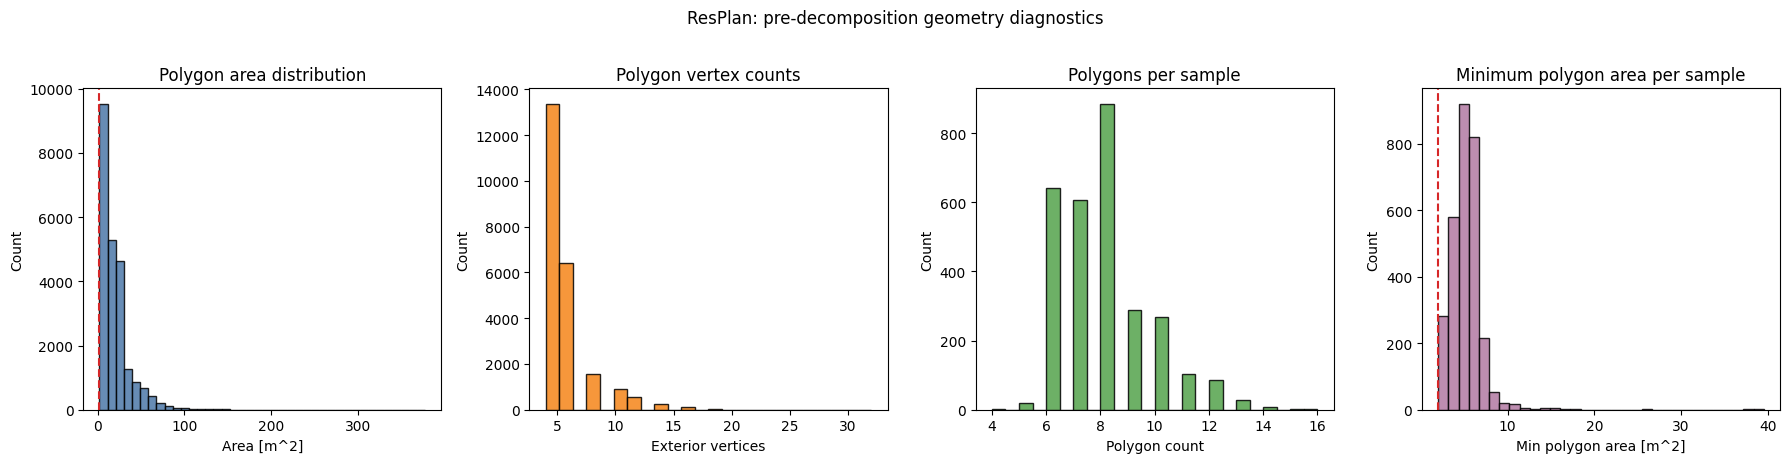

In [2]:
PREPROCESSED_INPUT_PATH = RESPLAN_DATA_DIR / "floorplans_aligned_quantized.pickle"
if not PREPROCESSED_INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Preprocessed floorplans not found at {PREPROCESSED_INPUT_PATH}. Run ResPlan_1_Preprocessing.ipynb first."
    )

with open(PREPROCESSED_INPUT_PATH, "rb") as f:
    floorplans_rooms_aligned_quantized = pickle.load(f)

from convexdecomp.diagnostics.datasets import (
    plot_resplan_input_dataset_diagnostics,
)

print(f"Loaded {len(floorplans_rooms_aligned_quantized)} preselected aligned floorplans from {PREPROCESSED_INPUT_PATH}")
print("")
input_diag_summary, input_diag_df = plot_resplan_input_dataset_diagnostics(
    floorplans_rooms_aligned_quantized,
    room_keys=("bathroom", "bedroom", "stair", "kitchen", "storage", "living"),
    min_area_m2=2.0,
    dataset_label="ResPlan",
)


### Preview the preselected aligned room floorplans
Inspect the first few aligned-and-quantized plans loaded from the already-selected preprocessing artifact.


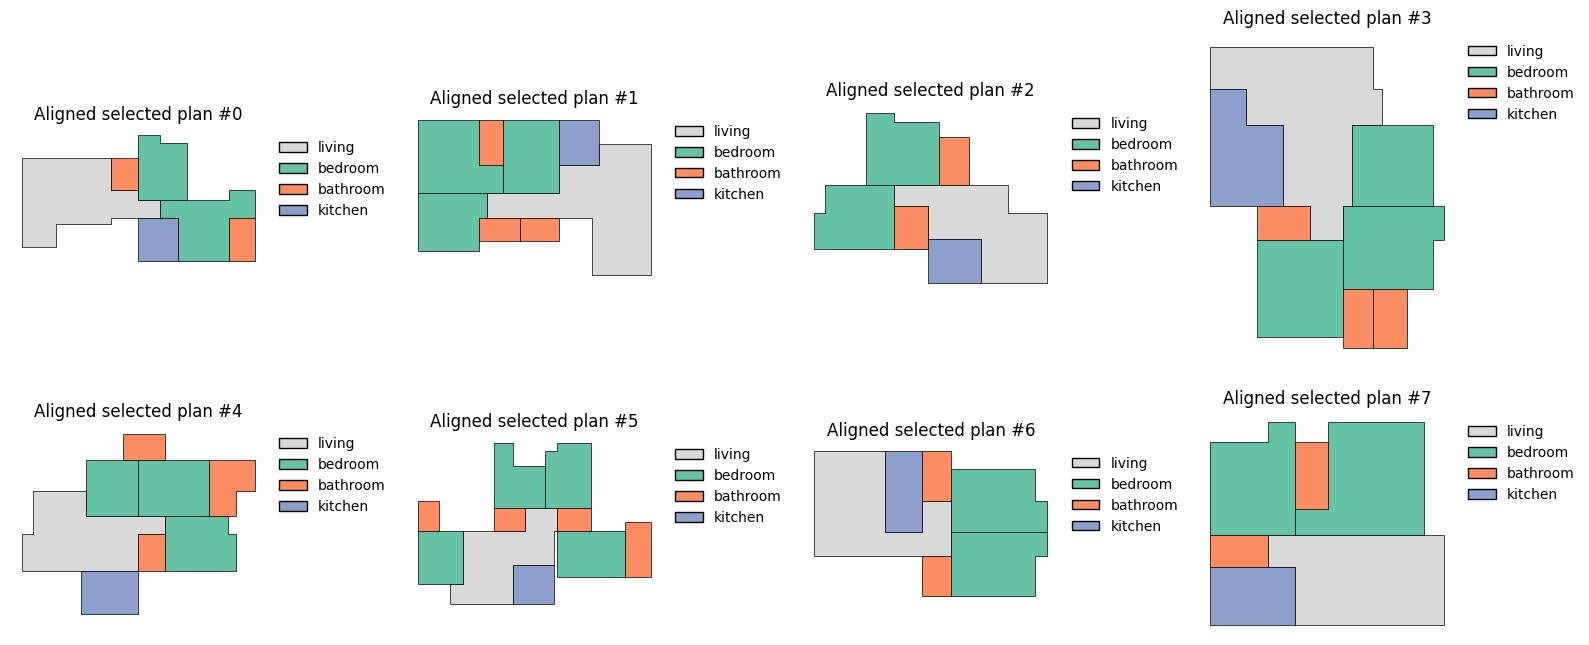

In [3]:
plot_floorplans_grid(floorplans_rooms_aligned_quantized, ncols=4, nrows=2, title_prefix="Aligned selected plan")


## Convex Room Split

Split all the non-convex rooms to convex pieces intelligently.


### Decompose non-convex rooms with shared H/V search diagnostics

**Inputs**
- The selected `floorplans_rooms_aligned_quantized` subset with `>= 3 concave rooms`
- Shared helpers `convexdecomp.resplan.decompose`, `convexdecomp.core.search`, `convexdecomp.core.convexity`, and `convexdecomp.diagnostics.search`
- Decomposition knobs `MIN_AREA_M2`, `MAX_DEPTH`, `MAX_VARIANTS_POLY`, `ADAPTIVE_INITIAL_DEPTH`, `WEIGHT_ROOMS`, `WEIGHT_COMPACT_SHOWCASE`, and `WEIGHT_COMPACT_DATASET`

**Steps**
1. Reuse the shared strict convexity helper so notebooks and scripts use the same polygon test.
2. Start each non-convex room search from a cheap depth budget, then retry with larger depth until the first successful parameter setting is found.
3. Score valid convex variants by room count and compactness, then keep the best room-wise reconstruction from that successful search setting.
4. Reuse the same helper and retry schedule for both the showcase plan and the dataset-wide run.

**Outputs**
- `best_plan`, `total_score`, `per_room`, `previews`
- `room_search_records`


[Best convex decomposition] showcase plan id=10171 (index 10)
  total score = 66.9052   (weights: rooms=1.0, compactness=20.0)
  - bathroom: score=24.7406, parts=5
  - bedroom : score=26.7213, parts=6
  - kitchen : score=5.7330, parts=1
  - living  : score=9.7102, parts=4


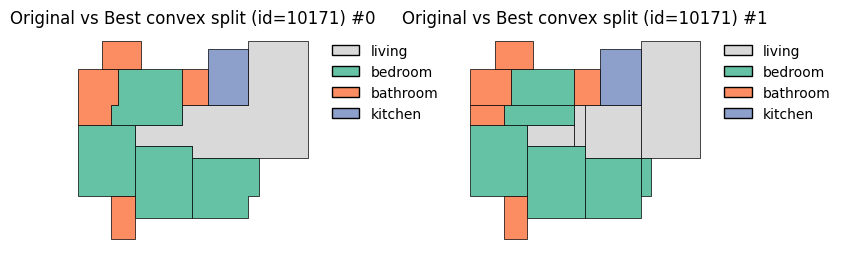

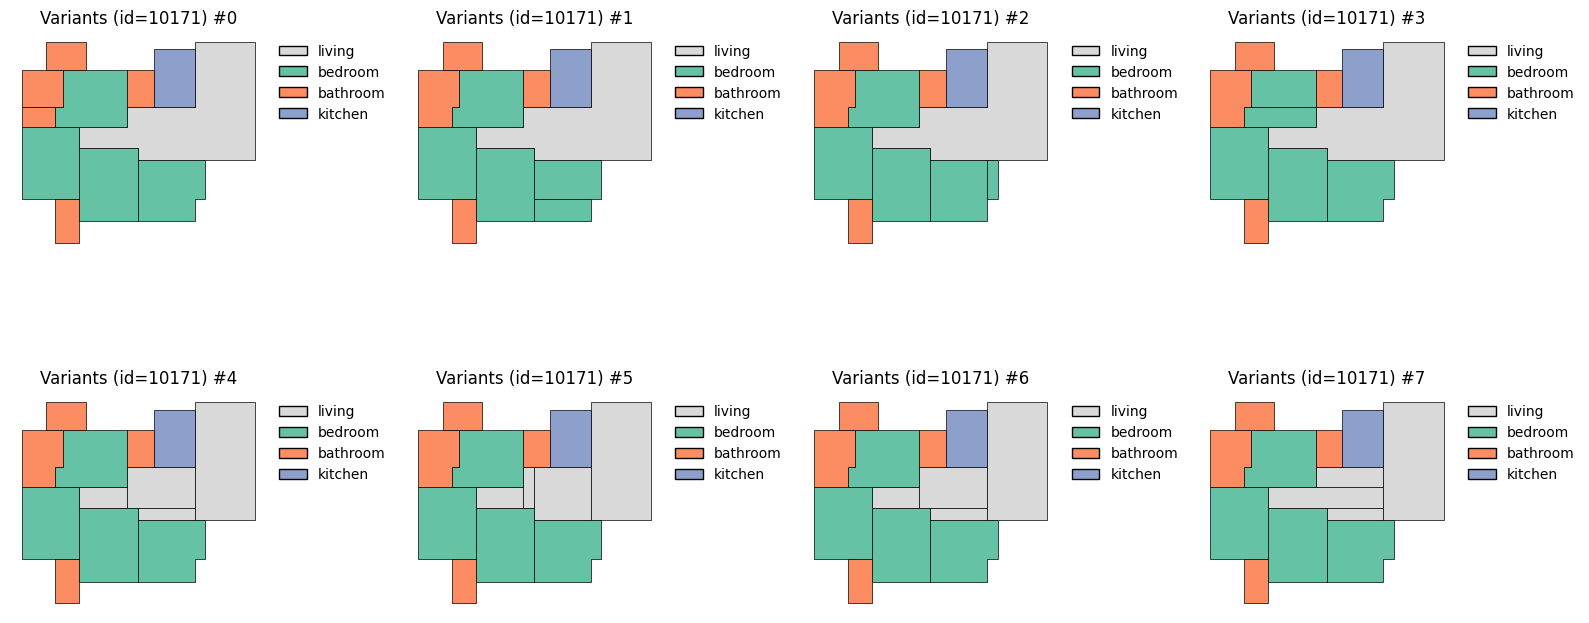

In [4]:
# === Pick the best convex decomposition per room on the first fixed showcase plan ===

from convexdecomp.core.search import AdaptiveSearchConfig
from convexdecomp.core.convexity import convexity_mask as shared_convexity_mask
from convexdecomp.resplan.decompose import (
    DEFAULT_ROOM_KEYS,
    FAILURE_REASON_LABELS,
    HVConvexDecompositionConfig,
    all_rooms_above_area,
    all_rooms_convex,
    decompose_polygon_hv_with_diagnostics,
    pick_best_convex_variant_per_room,
    plan_has_rooms,
)
from convexdecomp.diagnostics.search import plot_tree_search_distributions

# Config
SHOWCASE_PLAN_IDS = [10171, 13737, 12600]
SHOWCASE_PLAN_COUNT = 3  # Number of showcase plans to render; can exceed SHOWCASE_PLAN_IDS to allow fallback plans
PLAN_IDX = next((i for i, fp in enumerate(floorplans_rooms_aligned_quantized) if fp.get("id") in SHOWCASE_PLAN_IDS), 9)
MIN_AREA_M2 = 2.0
MAX_DEPTH = 8
MAX_VARIANTS_POLY = 64
ADAPTIVE_INITIAL_DEPTH = 4
ADAPTIVE_DEPTH_STEP = 1
WEIGHT_ROOMS = 1.0
WEIGHT_COMPACT_SHOWCASE = 20.0
WEIGHT_COMPACT_DATASET = 10.0
ROOM_KEYS = set(DEFAULT_ROOM_KEYS)

showcase_cfg = HVConvexDecompositionConfig(
    min_area_m2=MIN_AREA_M2,
    max_depth=MAX_DEPTH,
    max_variants_poly=MAX_VARIANTS_POLY,
    weight_rooms=WEIGHT_ROOMS,
    weight_compact=WEIGHT_COMPACT_SHOWCASE,
    track_time=True,
    room_keys=DEFAULT_ROOM_KEYS,
    adaptive_search=AdaptiveSearchConfig(
        enabled=True,
        initial_depth=ADAPTIVE_INITIAL_DEPTH,
        max_depth=MAX_DEPTH,
        depth_step=ADAPTIVE_DEPTH_STEP,
    ),
)
dataset_cfg = HVConvexDecompositionConfig(
    min_area_m2=MIN_AREA_M2,
    max_depth=MAX_DEPTH,
    max_variants_poly=MAX_VARIANTS_POLY,
    weight_rooms=WEIGHT_ROOMS,
    weight_compact=WEIGHT_COMPACT_DATASET,
    track_time=True,
    room_keys=DEFAULT_ROOM_KEYS,
    adaptive_search=AdaptiveSearchConfig(
        enabled=True,
        initial_depth=ADAPTIVE_INITIAL_DEPTH,
        max_depth=MAX_DEPTH,
        depth_step=ADAPTIVE_DEPTH_STEP,
    ),
)

_convexity_mask = shared_convexity_mask

# ---- Run on the selected plan, report and plot ----
plan2 = floorplans_rooms_aligned_quantized[PLAN_IDX]
best_plan, total_score, per_room, previews, room_search_records = pick_best_convex_variant_per_room(
    plan2,
    showcase_cfg,
    plot_variants=True,
    max_previews=48,
)

print(f"[Best convex decomposition] showcase plan id={plan2.get('id')} (index {PLAN_IDX})")
print(
    f"  total score = {total_score:.4f}   "
    f"(weights: rooms={showcase_cfg.weight_rooms}, compactness={showcase_cfg.weight_compact})"
)
for key, score in per_room.items():
    print(f"  - {key:8s}: score={score:.4f}, parts={len(best_plan.get(key, []))}")

plot_floorplans_grid(
    [plan2, best_plan],
    ncols=2,
    title_prefix=f"Original vs Best convex split (id={plan2.get('id')})",
)

if previews:
    plot_floorplans_grid(previews, ncols=4, nrows=3, title_prefix=f"Variants (id={plan2.get('id')})")


### Run the convex decomposition across the preselected aligned subset

**Inputs**
- `floorplans_rooms_aligned_quantized` loaded from the preprocessing artifact
- Shared H/V decomposition config `dataset_cfg` with adaptive depth retries

**Steps**
1. Reuse `pick_best_convex_variant_per_room()` for every preselected aligned plan.
2. Store the best convex reconstruction in `floorplans_best_convex`.
3. Collect room-level search diagnostics for every decomposed room search, including how many retry attempts were needed.
4. Track plan-level total score, room-part counts, remaining non-convex polygons, and the deepest successful retry level used in that plan.

**Outputs**
- `floorplans_best_convex`
- `scores_summary`
- `room_search_diagnostics_df`


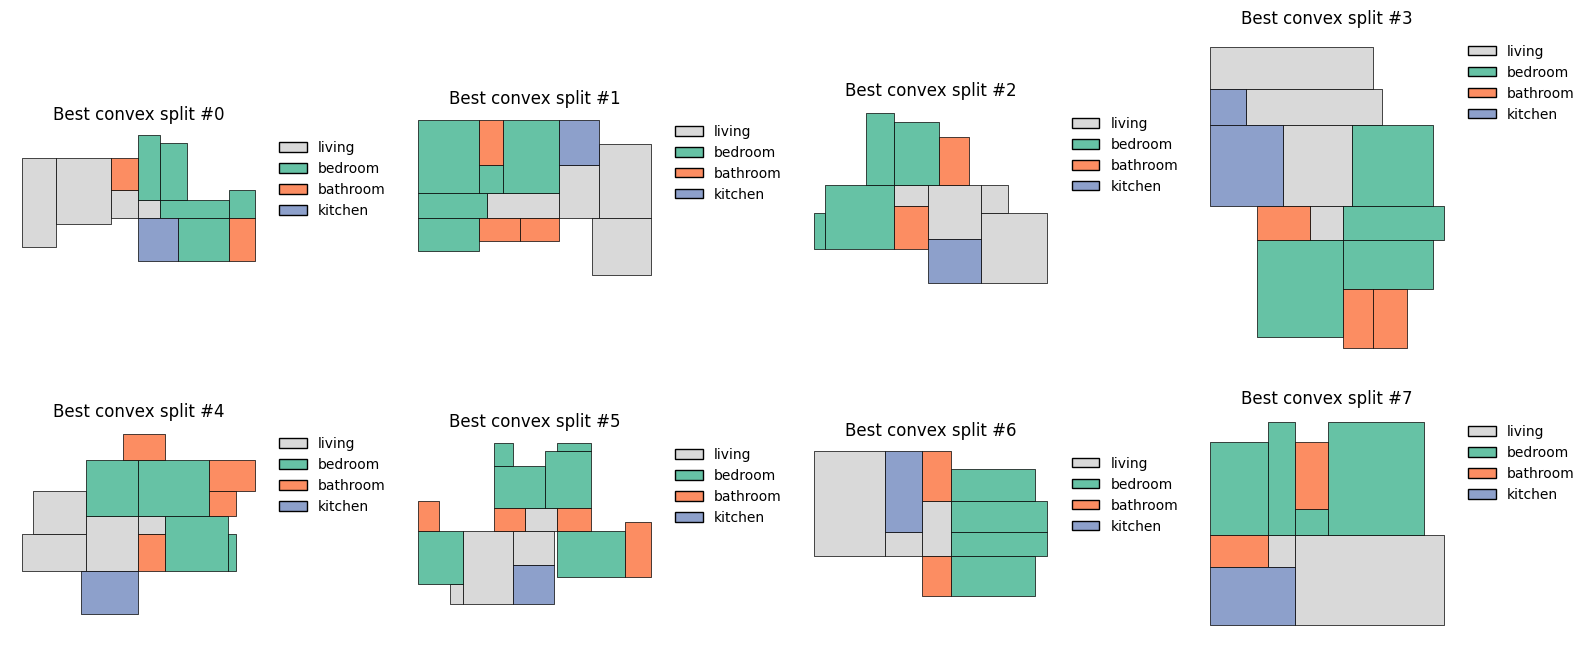

In [5]:
floorplans_best_convex = []
scores_summary = []
room_search_records_all = []

for i, plan in enumerate(floorplans_rooms_aligned_quantized):
    best_plan, total_score, per_room, _, room_records = pick_best_convex_variant_per_room(
        plan,
        dataset_cfg,
        plot_variants=False,
    )
    floorplans_best_convex.append(best_plan)
    room_search_records_all.extend(room_records)

    room_polys = [
        poly
        for key, polys in best_plan.items()
        if key in ROOM_KEYS
        for poly in polys
        if isinstance(poly, Polygon) and not poly.is_empty
    ]
    nonconvex_remaining = int((~_convexity_mask(room_polys)).sum()) if room_polys else 0
    successful_room_searches = int(sum(1 for record in room_records if record["success"]))
    failed_room_searches = int(sum(1 for record in room_records if not record["success"]))
    fallback_room_searches = int(sum(1 for record in room_records if record.get("fallback_used")))
    decomposition_time_seconds = float(sum(float(record.get("time_seconds") or 0.0) for record in room_records))
    search_attempt_counts = [int(record.get("search_attempt_count", 0) or 0) for record in room_records]
    used_depths = [
        int(record["search_depth_used"])
        for record in room_records
        if record.get("search_depth_used") is not None
    ]
    retried_room_searches = int(sum(1 for attempts in search_attempt_counts if attempts > 1))
    total_search_attempts = int(sum(search_attempt_counts))
    plan_decomposition_failed = failed_room_searches > 0

    scores_summary.append({
        "plan_idx": i,
        "plan_id": plan.get("id"),
        "total_score": total_score,
        "nonconvex_remaining": nonconvex_remaining,
        "successful_room_searches": successful_room_searches,
        "failed_room_searches": failed_room_searches,
        "fallback_room_searches": fallback_room_searches,
        "retried_room_searches": retried_room_searches,
        "total_search_attempts": total_search_attempts,
        "max_search_depth_used": max(used_depths, default=0),
        "decomposition_time_seconds": decomposition_time_seconds,
        "plan_decomposition_failed": plan_decomposition_failed,
        **{f"{key}_parts": len(best_plan.get(key, [])) for key in DEFAULT_ROOM_KEYS},
    })

scores_summary_df = pd.DataFrame(scores_summary)
room_search_diagnostics_df = pd.DataFrame(room_search_records_all)

plot_floorplans_grid(floorplans_best_convex, ncols=4, title_prefix="Best convex split")


### Expose the decomposed subset as the final dataset
Set `floorplans_final` to the convex-decomposed subset directly because geometry cleanup and minimum-room-area filtering now happen in preprocessing.


In [6]:
floorplans_final = floorplans_best_convex
print(f"Final exported dataset size: {len(floorplans_final)}")


Final exported dataset size: 2935


### Save the single final dataset
Persist the decomposed `floorplans_final` subset to `data/resplan/floorplans.pickle`.


In [7]:
import pickle

output_dir = RESPLAN_DATA_DIR
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "floorplans.pickle"
with open(output_path, "wb") as f:
    pickle.dump(floorplans_final, f)

print(f"Saved {len(floorplans_final)} floorplans to {output_path}")


Saved 2935 floorplans to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/ConvexDecomp/data/resplan/floorplans.pickle


## Convex decomposition showcases
Resolve a configurable number of showcase aligned plans from the selected subset, prioritize the configured ids first, and reuse them for detailed convex split inspection and final before/after comparisons.
Set `SHOWCASE_PLAN_COUNT` in the configuration cell to control how many showcase cases are rendered.


In [8]:
resolved_showcase_ids = [pid for pid in SHOWCASE_PLAN_IDS if any(fp.get("id") == pid for fp in floorplans_rooms_aligned_quantized)]
if len(resolved_showcase_ids) < SHOWCASE_PLAN_COUNT:
    fallback_ids = [fp.get("id") for fp in floorplans_rooms_aligned_quantized if fp.get("id") not in resolved_showcase_ids]
    resolved_showcase_ids.extend(fallback_ids[: max(0, SHOWCASE_PLAN_COUNT - len(resolved_showcase_ids))])
else:
    resolved_showcase_ids = resolved_showcase_ids[:SHOWCASE_PLAN_COUNT]

if not resolved_showcase_ids:
    raise ValueError("No showcase plans are available in the preprocessing artifact.")

TARGET_ID = resolved_showcase_ids[0]
fp_aligned = next(fp for fp in floorplans_rooms_aligned_quantized if fp.get("id") == TARGET_ID)

print(f"Loaded aligned showcase plan id={TARGET_ID} for detailed convex split inspection.")


Loaded aligned showcase plan id=10171 for detailed convex split inspection.


### Inspect convex split variants for the first showcase plan
Show only one aligned-vs-convex comparison for the primary showcase example, then inspect the non-convex room variants below it using the same room colors and the same overall plot extent as in the model view.


[Best convex decomposition] aligned plan id=10171
  total score = 66.9052   (weights: rooms=1.0, compactness=20.0)
  - bathroom: score=24.7406, parts=5
  - bedroom : score=26.7213, parts=6
  - kitchen : score=5.7330, parts=1
  - living  : score=9.7102, parts=4
Non-convex polygons in aligned plan: 4
Final convexified rooms stats:
  polygons: 16
  vertices: 80
  total_area_m2: 184.60031947661585


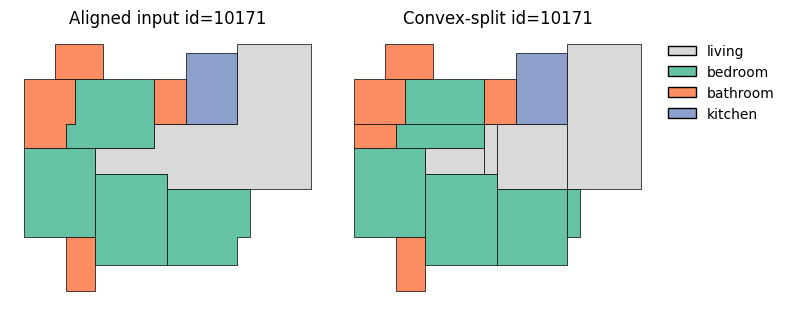

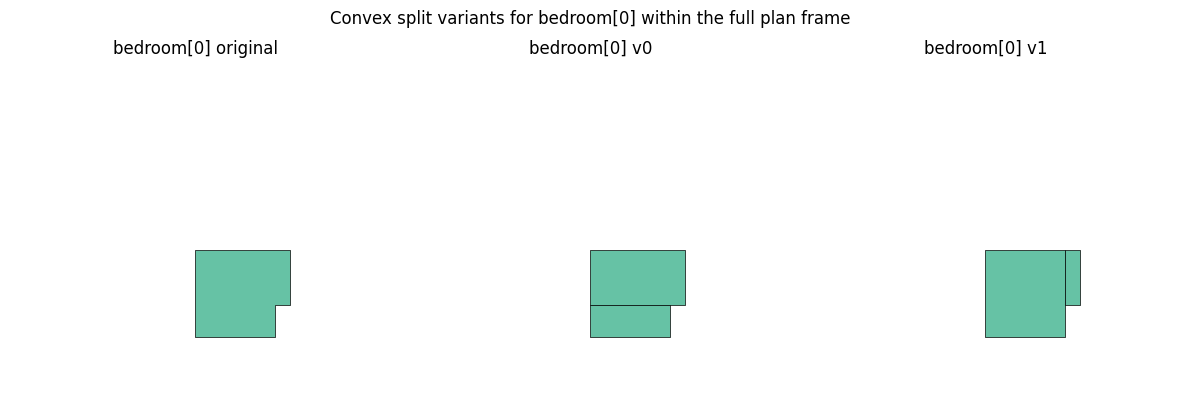

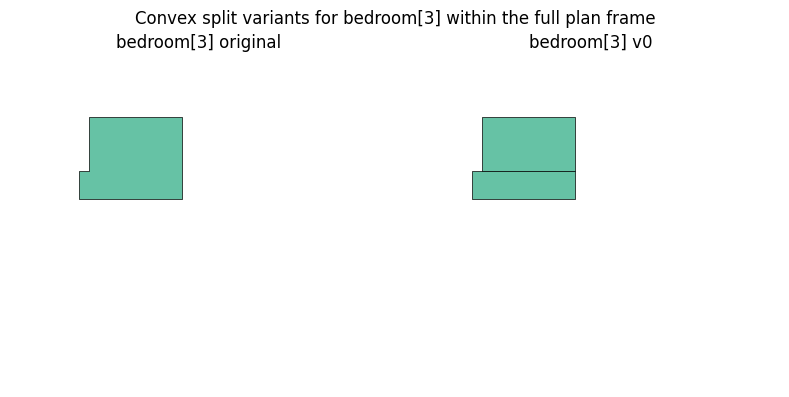

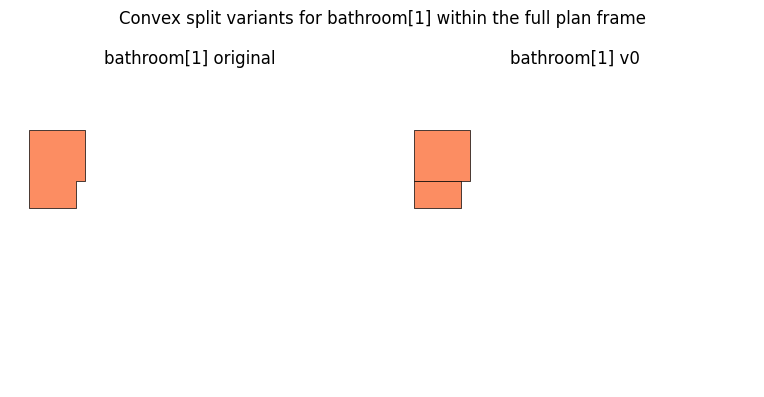

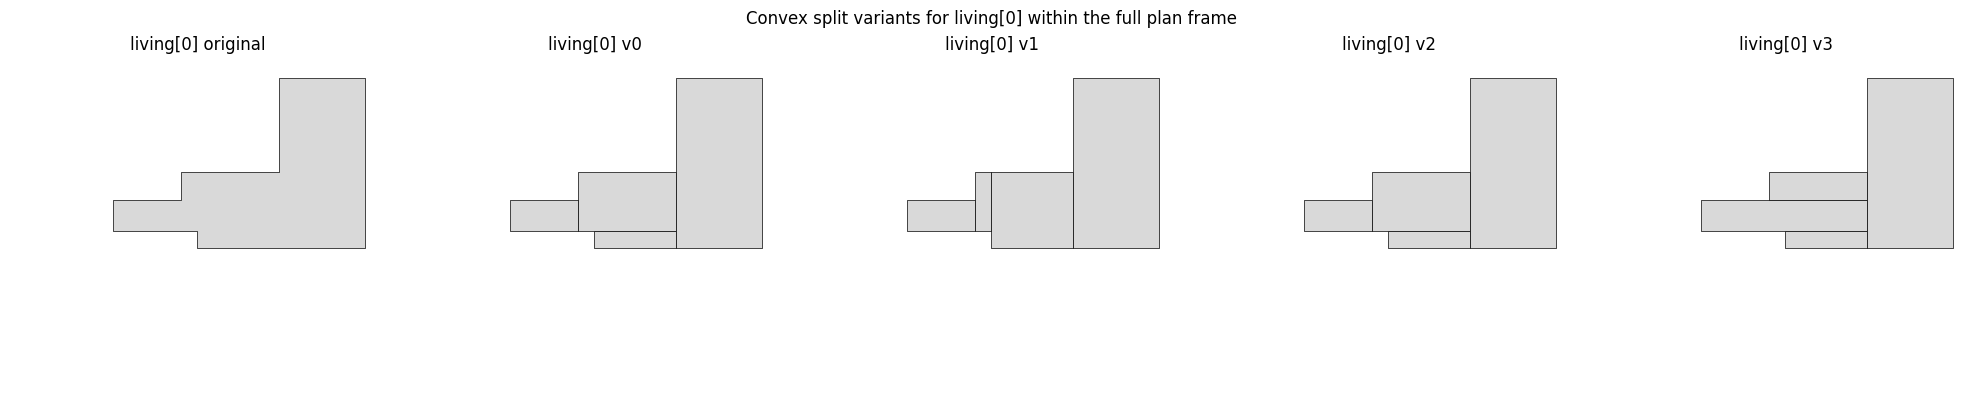

In [9]:
# --- Convex room split on the aligned plan using existing helpers ---

plan_edge = {"id": fp_aligned.get("id")}
for rk in ROOM_KEYS:
    polys = [
        poly for poly in fp_aligned.get(rk, [])
        if isinstance(poly, Polygon) and not poly.is_empty
    ]
    if polys:
        plan_edge[rk] = polys

room_entries = [
    (rk, j, poly)
    for rk in ROOM_KEYS
    for j, poly in enumerate(plan_edge.get(rk, []))
    if isinstance(poly, Polygon) and not poly.is_empty
]
nonconvex_mask = ~_convexity_mask([poly for _, _, poly in room_entries]) if room_entries else np.zeros(0, dtype=bool)
nonconvex = [entry for entry, keep in zip(room_entries, nonconvex_mask) if keep]

best_plan, total_score, per_room_scores, previews, room_search_records_showcase = pick_best_convex_variant_per_room(
    plan_edge,
    showcase_cfg,
    plot_variants=False,
    max_previews=0,
)

print(f"[Best convex decomposition] aligned plan id={plan_edge['id']}")
print(
    f"  total score = {total_score:.4f}   "
    f"(weights: rooms={showcase_cfg.weight_rooms}, compactness={showcase_cfg.weight_compact})"
)
for key, score in per_room_scores.items():
    print(f"  - {key:8s}: score={score:.4f}, parts={len(best_plan.get(key, []))}")
print(f"Non-convex polygons in aligned plan: {len(nonconvex)}")

fp_convex_edge = dict(fp_aligned)
for rk in ROOM_KEYS:
    if rk in best_plan:
        fp_convex_edge[rk] = best_plan[rk]

convex_poly_count = sum(len(v) for k, v in best_plan.items() if k in ROOM_KEYS)
convex_vert_count = sum(
    len(list(poly.exterior.coords))
    for k, v in best_plan.items() if k in ROOM_KEYS
    for poly in v
)
convex_area = sum(
    poly.area
    for k, v in best_plan.items() if k in ROOM_KEYS
    for poly in v
)

print("Final convexified rooms stats:")
print("  polygons:", convex_poly_count)
print("  vertices:", convex_vert_count)
print("  total_area_m2:", convex_area)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_plan(fp_aligned, ax=axes[0], legend=False, title=f"Aligned input id={TARGET_ID}")
axes[0].set_axis_off()
plot_plan(fp_convex_edge, ax=axes[1], legend=True, title=f"Convex-split id={TARGET_ID}")
axes[1].set_axis_off()
plt.tight_layout()

plt.show()

room_polys_all = [
    poly
    for rk in ROOM_KEYS
    for poly in fp_aligned.get(rk, [])
    if isinstance(poly, Polygon) and not poly.is_empty
]
minx = min(poly.bounds[0] for poly in room_polys_all)
miny = min(poly.bounds[1] for poly in room_polys_all)
maxx = max(poly.bounds[2] for poly in room_polys_all)
maxy = max(poly.bounds[3] for poly in room_polys_all)
pad = max(0.5, 0.06 * max(maxx - minx, maxy - miny, 1.0))

for rk, j, poly in nonconvex:
    variant_records = decompose_polygon_hv_with_diagnostics(poly, showcase_cfg)["variant_records"]
    variants = [record["parts"] for record in variant_records]
    if not variants:
        continue

    fig, axes = plt.subplots(1, len(variants) + 1, figsize=(4 * (len(variants) + 1), 4))
    axes = np.atleast_1d(axes)

    original_room_plan = {"id": plan_edge["id"], rk: [poly]}
    plot_plan(original_room_plan, ax=axes[0], legend=False, title=f"{rk}[{j}] original")
    axes[0].set_xlim(minx - pad, maxx + pad)
    axes[0].set_ylim(miny - pad, maxy + pad)
    axes[0].set_aspect("equal", "box")
    axes[0].set_axis_off()

    for k, parts in enumerate(variants, start=1):
        variant_plan = {"id": plan_edge["id"], rk: parts}
        plot_plan(variant_plan, ax=axes[k], legend=False, title=f"{rk}[{j}] v{k - 1}")
        axes[k].set_xlim(minx - pad, maxx + pad)
        axes[k].set_ylim(miny - pad, maxy + pad)
        axes[k].set_aspect("equal", "box")
        axes[k].set_axis_off()

    fig.suptitle(f"Convex split variants for {rk}[{j}] within the full plan frame")
    plt.tight_layout()

    plt.show()


### Summarize convex coverage and the final exported dataset

Report three dataset-level counts from the current pipeline run:
1. Plans whose post-decomposition rooms are all convex.
2. Plans whose post-decomposition rooms are all convex and all at least `MIN_AREA_M2`.
3. The single exported dataset `floorplans_final`, which is written directly from the best convex reconstruction.


In [10]:
N_TOTAL = len(floorplans_rooms_aligned_quantized)
convex_plan_flags = []
convex_and_big_flags = []
convex_success_flags = []
failed_plan_flags = scores_summary_df["plan_decomposition_failed"].fillna(False).astype(bool).to_numpy(dtype=bool)

for best_plan, plan_failed in zip(floorplans_best_convex, failed_plan_flags, strict=False):
    has_rooms = plan_has_rooms(best_plan, tuple(ROOM_KEYS))
    is_convex = has_rooms and all_rooms_convex(best_plan, tuple(ROOM_KEYS))
    convex_plan_flags.append(is_convex)
    convex_and_big_flags.append(is_convex and all_rooms_above_area(best_plan, MIN_AREA_M2, tuple(ROOM_KEYS)))
    convex_success_flags.append(is_convex and not plan_failed)

n_convex_plans = int(np.sum(convex_plan_flags))
n_convex_and_big = int(np.sum(convex_and_big_flags))
n_convex_success = int(np.sum(convex_success_flags))
n_failed_plans = int(np.sum(failed_plan_flags))
n_final = len(floorplans_final)

pct_convex = 100.0 * n_convex_plans / N_TOTAL if N_TOTAL else 0.0
pct_convex_big_all = 100.0 * n_convex_and_big / N_TOTAL if N_TOTAL else 0.0
pct_convex_success = 100.0 * n_convex_success / N_TOTAL if N_TOTAL else 0.0
pct_failed = 100.0 * n_failed_plans / N_TOTAL if N_TOTAL else 0.0
pct_final = 100.0 * n_final / N_TOTAL if N_TOTAL else 0.0

print("=== Dataset-level pipeline summary ===")
print(f"Loaded preselected aligned subset: {N_TOTAL}")
print(f"Plans with at least one failed room decomposition: {n_failed_plans} / {N_TOTAL} ({pct_failed:.1f}%)")
print(f"Convex after H/V decomposition: {n_convex_plans} / {N_TOTAL} ({pct_convex:.1f}%)")
print(
    f"Diagnostic check: convex and all rooms >= {MIN_AREA_M2:.1f} m^2 after decomposition: "
    f"{n_convex_and_big} / {N_TOTAL} ({pct_convex_big_all:.1f}%)"
)
print(
    f"Convex output with no failed room decomposition: "
    f"{n_convex_success} / {N_TOTAL} ({pct_convex_success:.1f}%)"
)
print(
    f"Final exported dataset (no extra post-decomposition geometry filter): "
    f"{n_final} / {N_TOTAL} ({pct_final:.1f}%)"
)


=== Dataset-level pipeline summary ===
Loaded preselected aligned subset: 2935
Plans with at least one failed room decomposition: 56 / 2935 (1.9%)
Convex after H/V decomposition: 2879 / 2935 (98.1%)
Diagnostic check: convex and all rooms >= 2.0 m^2 after decomposition: 2879 / 2935 (98.1%)
Convex output with no failed room decomposition: 2879 / 2935 (98.1%)
Final exported dataset (no extra post-decomposition geometry filter): 2935 / 2935 (100.0%)
